# Aufgabe 5
## Bestimmung der Werte für Verdampfungswärme mit Fit
FÜr Aufgabe 5 sollen für aus den Messwerten die Verdampfungswärme, mittels der Clausius-Clapeyron-Gleichung, ermitteln. DIese lautet wie folgt:
$$\frac{d p_s}{dT} = \frac{Q_{23}}{T \cdot \Delta V_m}$$
Wenn man das $dT$ auf die andere Seite zieht so kann man beide Seiten integrieren um die Differentialgelichung zu lösen. 
$$\int dp_s = \int \frac{Q_{23}}{T \cdot \Delta V_m} dT$$
Löst man beide integrale so kommt man auf die folgende Gleichung:
$$p_s(T) = \frac{Q_{23}}{\Delta V_m} \cdot \ln(T) + C$$
Diese gleichung kann nun mit dem Python Modul `scipy.optimize.curve_fit`angepasst werden und es kann der Wert für $Q_{23}$ bestimmt werden.

Fit-Steigung a = -33.9053, Achsenabschnitt = 15.8834
Berechnete Verdampfungswärme Q_23 = 281.89 J/mol


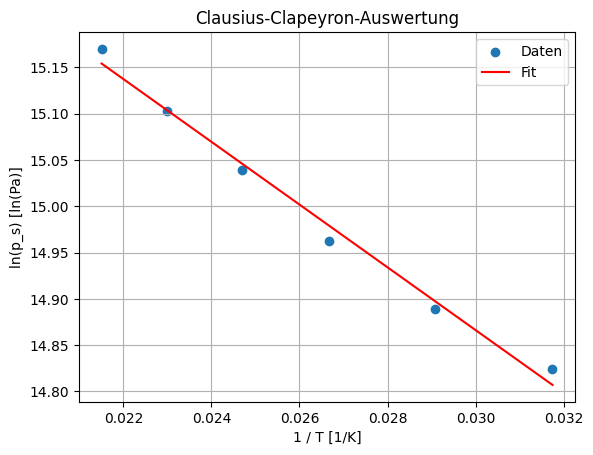

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Beispiel-Daten: Temperatur in K und p_s in Pa (diese musst du einfügen)
T = np.array([31.5, 34.4, 37.5, 40.5, 43.5, 46.5])
p_s = np.array([2742000, 2925000, 3150000, 3400000, 3625000, 3875000])

# Linearisierte Clausius-Clapeyron-Darstellung
inv_T = 1 / T
ln_p = np.log(p_s)

# Lineares Modell für ln(p) = -Q/(R*T) + C
def linear_model(x, a, b):
    return a * x + b

params, _ = curve_fit(linear_model, inv_T, ln_p)
a, b = params

# Gaskonstante in J/mol·K
R = 8.314
Q_23 = -a * R

print(f"Fit-Steigung a = {a:.4f}, Achsenabschnitt = {b:.4f}")
print(f"Berechnete Verdampfungswärme Q_23 = {Q_23:.2f} J/mol")

# Plot der linearen Anpassung
plt.figure()
plt.scatter(inv_T, ln_p, label='Daten')
plt.plot(inv_T, linear_model(inv_T, *params), color='red', label='Fit')
plt.xlabel('1 / T [1/K]')
plt.ylabel('ln(p_s) [ln(Pa)]')
plt.title('Clausius-Clapeyron-Auswertung')
plt.legend()
plt.grid()
plt.show()

# OPTIONAL: Potenzgesetz-Fit in der Nähe von T_k
# T_k = 49.5  # Kritische Temperatur in K (bitte eintragen)
# x = T / T_k
# def power_law(x, A):
#     return A * (1 - x)**(3/8)

# Q_values = ...  # z.B. aus vorheriger Berechnung bei jeder Temperatur

# # Curve fit
# params_potenz, _ = curve_fit(power_law, x, Q_values)
# A_fit = params_potenz[0]

# # Plot
# plt.figure()
# plt.scatter(x, Q_values, label='Q(T/Tk) Daten')
# plt.plot(x, power_law(x, A_fit), label=f'Fit: A={(A_fit):.2f}', color='green')
# plt.xlabel('T / T_k')
# plt.ylabel('Q_23(T) [J/mol]')
# plt.title('Potenzgesetz-Fit für Verdampfungswärme')
# plt.legend()
# plt.grid()
# plt.show()


T = 31.50 K → Q_23 = 189.85 J/mol
T = 34.40 K → Q_23 = 228.72 J/mol
T = 37.50 K → Q_23 = 289.02 J/mol
T = 40.50 K → Q_23 = 317.53 J/mol
T = 43.50 K → Q_23 = 343.57 J/mol
T = 46.50 K → Q_23 = 386.60 J/mol


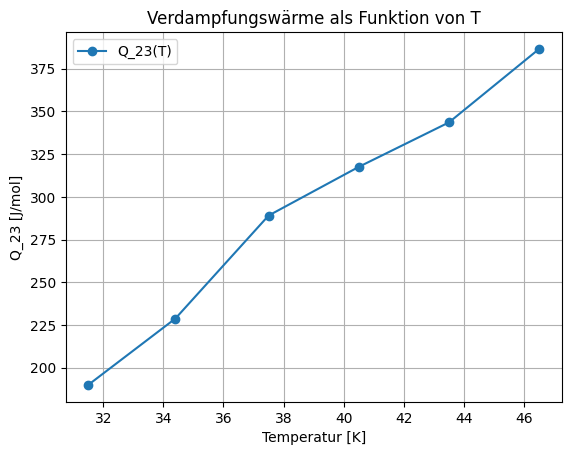

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Beispielhafte Daten (bitte mit echten Messwerten ersetzen)
T = np.array([31.5, 34.4, 37.5, 40.5, 43.5, 46.5])
p_s = np.array([2742000, 2925000, 3150000, 3400000, 3625000, 3875000])    # Sättigungsdampfdrucke in Pa

# Gaskonstante
R = 8.314  # J/mol·K

# dp_s/dT numerisch mit zentralem Differenzenquotient
dp_dT = np.zeros_like(p_s)
dp_dT[1:-1] = (p_s[2:] - p_s[:-2]) / (T[2:] - T[:-2])

# Randpunkte ggf. mit einseitiger Differenz (optional)
dp_dT[0] = (p_s[1] - p_s[0]) / (T[1] - T[0])
dp_dT[-1] = (p_s[-1] - p_s[-2]) / (T[-1] - T[-2])

# Q_23 berechnen: Q = R * T^2 / p * dp/dT
Q_23 = R * T**2 / p_s * dp_dT

# Ausgabe
for Ti, Qi in zip(T, Q_23):
    print(f"T = {Ti:.2f} K → Q_23 = {Qi:.2f} J/mol")

# Plot (für spätere Fit-Darstellung)
plt.plot(T, Q_23, 'o-', label='Q_23(T)')
plt.xlabel("Temperatur [K]")
plt.ylabel("Q_23 [J/mol]")
plt.grid()
plt.title("Verdampfungswärme als Funktion von T")
plt.legend()
plt.show()
